# T² Visualization: Base, Target, RCPM, and Ours

Visualizes distributions on the torus T² = S¹×S¹ similar to Figure 5 in the RCPM paper.

In [5]:
import sys
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['HIP_VISIBLE_DEVICES'] = '5'  # or '0', '4', '5', '6', '7' - any idle GPU
%load_ext autoreload
%autoreload 2
# Add RCPM to path (relative to project root)
sys.path.insert(0, 'rcpm')

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
from jax import random

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
import optax

# RCPM imports
import flows as rcpm_flows
import manifolds as rcpm_manifolds

# Our method imports
from src.base import ExperimentConfig
from src.manifolds import get as get_manifold
import src.densities as densities
from src.embeddings import GromovDistanceEmbedding, build_landmarks
from src.networks import build_network
from src.solvers import ArgminSolver
from src.losses import SemiDualLoss
from src.trainers import SemiDualTrainer
from src.metrics import (
    compute_kl_divergence, 
    compute_kl_divergence_autodiff,
    compute_ess,
)

# Import torus visualization helpers
from torus_viz_helpers import samples_to_angles, angles_to_samples

print(f"Running on: {jax.devices()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running on: [RocmDevice(id=0)]


In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================
N_SAMPLES = 1024        # samples to visualize
SEED = 42
RCPM_GAMMA = 0.1
RCPM_N_ITERS = 1000      # RCPM training iterations

# Landmark selection method: "fps" or "random"
LANDMARK_METHOD = "random"
FPS_CANDIDATES = 5000    # number of candidates for FPS selection

In [7]:
# =============================================================================
# TORUS VISUALIZATION UTILITIES
# =============================================================================
# Note: samples_to_angles, angles_to_samples, angles_to_3d_torus are imported from torus_viz_helpers.py

def create_torus_surface(R=2.0, r=0.8, n_theta1=100, n_theta2=50):
    """Create 3D torus mesh for surface plotting."""
    theta1 = np.linspace(0, 2*np.pi, n_theta1)
    theta2 = np.linspace(0, 2*np.pi, n_theta2)
    theta1, theta2 = np.meshgrid(theta1, theta2)
    
    x = (R + r * np.cos(theta2)) * np.cos(theta1)
    y = (R + r * np.cos(theta2)) * np.sin(theta1)
    z = r * np.sin(theta2)
    return x, y, z, theta1, theta2


def compute_density_on_torus(samples_angles, n_grid=50):
    """
    Estimate density on the flat torus [0, 2π)² using KDE.
    Returns density grid for coloring the 3D torus surface.
    
    Uses periodic KDE to handle wraparound.
    """
    # Convert to numpy
    angles = np.array(samples_angles)
    
    # Create grid
    theta1_grid = np.linspace(0, 2*np.pi, n_grid)
    theta2_grid = np.linspace(0, 2*np.pi, n_grid)
    T1, T2 = np.meshgrid(theta1_grid, theta2_grid)
    positions = np.vstack([T1.ravel(), T2.ravel()])
    
    # Periodic KDE: replicate data in 3x3 grid
    offsets = [-2*np.pi, 0, 2*np.pi]
    replicated = []
    for o1 in offsets:
        for o2 in offsets:
            replicated.append(angles + np.array([o1, o2]))
    replicated = np.vstack(replicated)
    
    try:
        kde = gaussian_kde(replicated.T, bw_method=0.15)
        density = kde(positions).reshape(T1.shape)
    except:
        density = np.ones(T1.shape)
    
    # Normalize
    density = (density - density.min()) / (density.max() - density.min() + 1e-8)
    return density, T1, T2

In [8]:
# =============================================================================
# RCPM DENSITY CLASSES (from unified_experiments)
# =============================================================================
from dataclasses import dataclass
from jax.scipy.stats import norm

def get_rcpm_zero(manifold):
    if hasattr(manifold, 'zero'):
        return manifold.zero()
    if hasattr(manifold, 'manifolds'):
        parts = [get_rcpm_zero(m) for m in manifold.manifolds]
        return jnp.concatenate(parts, axis=-1)
    raise ValueError(f"Cannot get zero for {type(manifold)}")


@dataclass
class RCPMSphereUniform:
    manifold: any
    
    def log_prob(self, xs):
        n_batch, D = xs.shape
        log_SA = jnp.log(2.0) + (D / 2.0) * jnp.log(jnp.pi) - jax.scipy.special.gammaln(D / 2.0)
        return jnp.full([n_batch], -log_SA)
    
    def sample(self, key, n_samples):
        xs = random.normal(key, shape=[n_samples, self.manifold.D])
        return self.manifold.projx(xs)
    
    def __hash__(self): return 0


@dataclass
class RCPMProductUniform:
    manifold: any
    
    def __post_init__(self):
        self.base_dists = [RCPMSphereUniform(manifold=m) for m in self.manifold.manifolds]
    
    def log_prob(self, xs):
        n_batch = xs.shape[0]
        log_probs = jnp.zeros([n_batch])
        d = 0
        for i, dist in enumerate(self.base_dists):
            D = self.manifold.manifolds[i].D
            log_probs += dist.log_prob(xs[:, d:d+D])
            d += D
        return log_probs
    
    def sample(self, key, n_samples):
        parts = []
        keys = jax.random.split(key, len(self.base_dists))
        for k, dist in zip(keys, self.base_dists):
            parts.append(dist.sample(k, n_samples))
        return jnp.concatenate(parts, axis=1)
    
    def __hash__(self): return 0


@dataclass
class RCPMWrappedNormal:
    manifold: any
    scale: float = 0.03
    
    def __post_init__(self):
        self.loc = get_rcpm_zero(self.manifold)
        self._scale = jnp.full(self.manifold.D - 1, self.scale)
    
    def log_prob(self, z):
        loc = jnp.broadcast_to(self.loc, z.shape)
        u = self.manifold.log(loc, z)
        y = self.manifold.zero_like(loc)
        v = self.manifold.transp(loc, y, u)
        v = self.manifold.squeeze_tangent(v)
        n_logprob = norm.logpdf(v, scale=self._scale).sum(axis=-1)
        logdet = self.manifold.logdetexp(loc, u)
        return n_logprob - logdet
    
    def sample(self, key, n_samples):
        v = self._scale * random.normal(key, [n_samples, self.manifold.D - 1])
        v = self.manifold.unsqueeze_tangent(v)
        loc = jnp.broadcast_to(self.loc, (n_samples, self.manifold.D))
        x = self.manifold.zero_like(loc)
        u = self.manifold.transp(x, loc, v)
        z = self.manifold.exponential_map(loc, u)
        return z
    
    def __hash__(self): return 0


@dataclass
class RCPMProductWrappedNormal:
    manifold: any
    scale: float = 0.3
    
    def __post_init__(self):
        self.component_dists = [
            RCPMWrappedNormal(manifold=m, scale=self.scale) 
            for m in self.manifold.manifolds
        ]
        self.loc = get_rcpm_zero(self.manifold)
    
    def log_prob(self, z):
        log_prob = jnp.zeros(z.shape[0])
        d = 0
        for i, dist in enumerate(self.component_dists):
            D = self.manifold.manifolds[i].D
            log_prob += dist.log_prob(z[:, d:d+D])
            d += D
        return log_prob
    
    def sample(self, key, n_samples):
        parts = []
        keys = jax.random.split(key, len(self.component_dists))
        for k, dist in zip(keys, self.component_dists):
            parts.append(dist.sample(k, n_samples))
        return jnp.concatenate(parts, axis=1)
    
    def __hash__(self): return 0

In [9]:
# =============================================================================
# BUILD AND TRAIN OUR METHOD
# =============================================================================
def build_and_train_ours():
    """Build and train our semi-dual OT model on T2."""
    print("Building our method...")
    
    exp_cfg = ExperimentConfig(
        manifold_name="T2",
        base_density="TorusUniform",
        target_density="TorusWrappedNormal",
        jax_platform="gpu",
    )

    manifold = get_manifold(exp_cfg.manifold_name)
    base = densities.get(manifold, exp_cfg.base_density)
    target = densities.get(manifold, exp_cfg.target_density)

    key = jax.random.PRNGKey(SEED)
    
    # Landmark selection: FPS or random
    n_landmarks = exp_cfg.model.n_landmarks
    n_base = n_landmarks // 2
    n_target = n_landmarks - n_base
    
    if LANDMARK_METHOD == "fps":
        print(f"Using FPS landmark selection ({n_landmarks} landmarks from {FPS_CANDIDATES} candidates)...")
        landmark_cfg_base = {"n_landmarks": n_base, "method": "fps", "fps_candidates": FPS_CANDIDATES}
        landmark_cfg_target = {"n_landmarks": n_target, "method": "fps", "fps_candidates": FPS_CANDIDATES}
        landmarks_base, key = build_landmarks(manifold, base, landmark_cfg_base, key)
        landmarks_target, key = build_landmarks(manifold, target, landmark_cfg_target, key)
    else:
        print(f"Using random landmark selection ({n_landmarks} landmarks)...")
        key, k1, k2 = jax.random.split(key, 3)
        landmarks_base = base.sample(k1, n_base)
        landmarks_target = target.sample(k2, n_target)
    
    landmarks = jnp.concatenate([landmarks_base, landmarks_target], axis=0)
    
    emb = GromovDistanceEmbedding(manifold=manifold, landmarks=landmarks)
    psi = build_network(
        phi=emb,
        network_type=exp_cfg.model.network_type,
        hidden_dims=exp_cfg.model.hidden_dims,
        use_layernorm=exp_cfg.model.use_layernorm,
        last_scale=exp_cfg.model.last_scale,
        activation=exp_cfg.model.activation,
        leaky_slope=exp_cfg.model.leaky_slope,
        softplus_beta=exp_cfg.model.softplus_beta,
        max_dist=exp_cfg.model.max_dist,
    )

    key, kx_init, kparams = jax.random.split(key, 3)
    x_init = base.sample(kx_init, 16)
    psi_vars = psi.init(kparams, x_init)
    psi_params = psi_vars["params"]

    solver = ArgminSolver(
        manifold=manifold, psi_module=psi,
        inner_steps=exp_cfg.solver.inner_steps,
        inner_lr=exp_cfg.solver.inner_lr,
        grad_clip=exp_cfg.solver.grad_clip,
        lr_decay=exp_cfg.solver.lr_decay,
        tolerance=exp_cfg.solver.tolerance,
        min_steps=exp_cfg.solver.min_steps,
        momentum=exp_cfg.solver.momentum,
        logsumexp_init=exp_cfg.solver.logsumexp_init,
        logsumexp_gamma=exp_cfg.solver.logsumexp_gamma,
        use_adam=exp_cfg.solver.use_adam,
        adam_beta1=exp_cfg.solver.adam_beta1,
        adam_beta2=exp_cfg.solver.adam_beta2,
        use_line_search=exp_cfg.solver.use_line_search,
        line_search_steps=exp_cfg.solver.line_search_steps,
    )


    loss_obj = SemiDualLoss(manifold=manifold, psi_module=psi, solver=solver)
    trainer = SemiDualTrainer(
        manifold=manifold, psi_module=psi, loss_fn=loss_obj, solver=solver,
        learning_rate=exp_cfg.training.learning_rate,
        lr_decay=exp_cfg.training.lr_decay,
        lr_decay_alpha=exp_cfg.training.lr_decay_alpha,
        n_steps=exp_cfg.training.n_steps,
    )

    state = trainer.init_state(psi_params)
    
    print(f"Training our method for {exp_cfg.training.n_steps} iterations (log_every={exp_cfg.training.log_every})...")
    state, history = trainer.train(
        state=state,
        base_density=base,
        target_density=target,
        key=key,
        n_steps=exp_cfg.training.n_steps,
        batch_size=exp_cfg.training.batch_size,
        log_every=exp_cfg.training.log_every,
        eval_every=exp_cfg.training.eval_every,
        eval_size=exp_cfg.training.eval_size,
        callbacks=[],
    )
    
    return {
        'manifold': manifold,
        'base': base,
        'target': target,
        'solver': solver,
        'state': state,
        'psi': psi,
    }


ours_exp = build_and_train_ours()

Building our method...


Using random landmark selection (128 landmarks)...
Training our method for 100 iterations (log_every=1)...
[     1] loss=-0.0032 | res=1.33e-06 | grad=6.96e+00 | 10.7s
[     2] loss=-0.1589 | res=1.46e-06 | grad=6.70e+00 | 0.3s
[     3] loss=-0.3115 | res=5.20e-07 | grad=6.72e+00 | 0.3s
[     4] loss=-0.4525 | res=5.41e-05 | grad=6.67e+00 | 0.3s
[     5] loss=-0.6018 | res=2.58e-05 | grad=6.88e+00 | 0.3s
[     6] loss=-0.7637 | res=3.21e-05 | grad=7.34e+00 | 0.3s
[     7] loss=-0.9514 | res=2.28e-04 | grad=7.83e+00 | 0.3s
[     8] loss=-1.0260 | res=1.99e-04 | grad=7.24e+00 | 0.3s
[     9] loss=-1.1099 | res=1.89e-05 | grad=6.52e+00 | 0.3s
[    10] loss=-1.2647 | res=3.91e-05 | grad=6.21e+00 | 0.3s
[    11] loss=-1.4459 | res=7.24e-05 | grad=6.16e+00 | 0.2s
[    12] loss=-1.6238 | res=2.96e-05 | grad=5.94e+00 | 0.3s
[    13] loss=-1.6598 | res=1.93e-05 | grad=5.22e+00 | 0.3s
[    14] loss=-1.8441 | res=7.65e-07 | grad=5.17e+00 | 0.3s
[    15] loss=-1.9559 | res=4.62e-08 | grad=4.72e+00

CONVERGENCE ANALYSIS
Solver: LineSearch(7 steps), steps=500, lr=0.005, tol=1e-06

Residual Statistics (N=1000):
  Min:    9.20e-16
  Median: 7.05e-08
  Mean:   1.47e-07
  P90:    3.23e-07
  P99:    1.31e-06
  Max:    3.27e-06

Convergence: 100.0% (1000/1000)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Residual Distribution | LineSearch(7), 500 steps, lr=0.005'}, xlabel='Gradient Residual (||∇f||)', ylabel='Count'>)

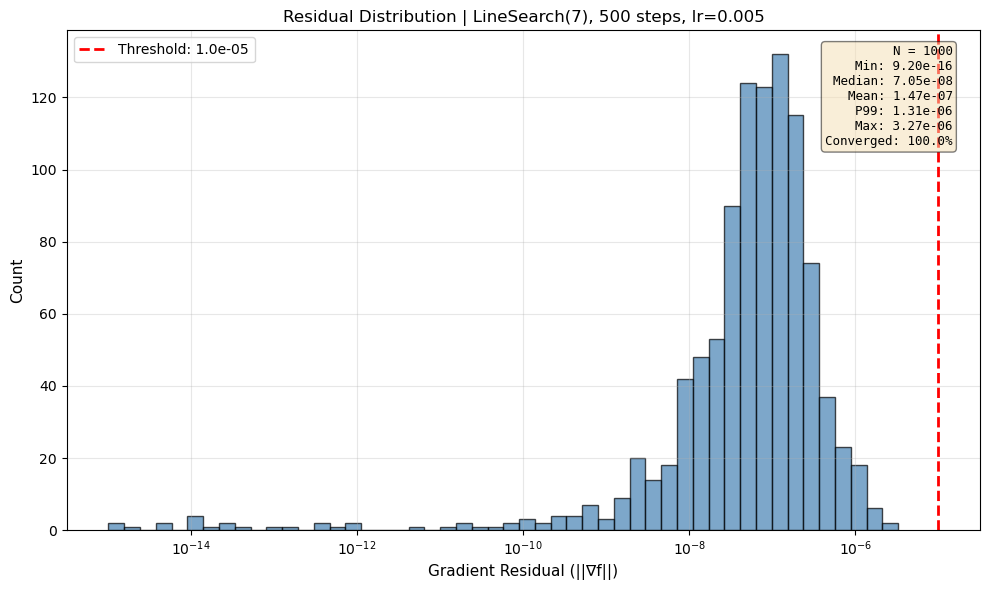

In [10]:
# Run convergence analysis
solver = ours_exp['solver']
psi_params = ours_exp['state'].params
manifold = ours_exp['manifold']
base = ours_exp['base']
target = ours_exp['target']

# Sample source and target points
key = jax.random.PRNGKey(42)
key1, key2 = jax.random.split(key)
xs = base.sample(key1, 1000)           # source samples (N, D)
y_samples = target.sample(key2, 1000)  # target samples for logsumexp init (K, D)

# Run analysis
analysis = solver.analyze_convergence(
    psi_params,
    xs,
    y_samples,
    threshold=0.1,
)

# Print report and plot histogram
solver.print_convergence_report(analysis, plot=True)


In [11]:
# =============================================================================
# BUILD AND TRAIN RCPM
# =============================================================================
def build_and_train_rcpm(n_iters=500, gamma=0.1, log_every=50):
    """Build and train RCPM flow model on T2."""
    print("Building RCPM...")
    
    manifold = rcpm_manifolds.Product(D=4, manifolds_str="S1,S1")
    base = RCPMProductUniform(manifold=manifold)
    target = RCPMProductWrappedNormal(manifold=manifold, scale=0.3)
    
    potential_cfg = {
        '_target_': 'flows.InfAffine',
        'n_components': 68,
        'init_alpha_mode': 'uniform',
        'init_alpha_linear_scale': 1.0,
        'init_alpha_minval': 0.4,
        'init_alpha_range': 0.01,
        'cost_gamma': gamma,
        'min_zero_gamma': None,
    }
    
    single_transform_cfg = {
        '_target_': 'flows.ExpMapFlow',
        'potential_cfg': potential_cfg,
    }
    
    flow = rcpm_flows.SequentialFlow(
        n_transforms=5,
        manifold=manifold,
        single_transform_cfg=single_transform_cfg,
    )
    
    key = jax.random.PRNGKey(SEED)
    key, k1, k2 = jax.random.split(key, 3)
    batch = base.sample(k1, 16)
    params = flow.init(k2, batch)
    
    optimizer = optax.adam(1e-3)
    opt_state = optimizer.init(params)
    
    @jax.jit
    def loss_fn(params, base_samples, base_log_probs):
        z, ldjs = flow.apply(params, base_samples)
        return (base_log_probs - ldjs - target.log_prob(z)).mean()
    
    @jax.jit
    def update(params, opt_state, base_samples, base_log_probs):
        loss, grads = jax.value_and_grad(loss_fn)(params, base_samples, base_log_probs)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return loss, params, opt_state
    
    print(f"Training RCPM for {n_iters} iterations (log_every={log_every})...")
    for i in range(n_iters):
        key, subkey = jax.random.split(key)
        base_samples = base.sample(subkey, 128)
        base_log_probs = base.log_prob(base_samples)
        loss, params, opt_state = update(params, opt_state, base_samples, base_log_probs)
        if (i + 1) % log_every == 0:
            print(f"  [{i+1:5d}] loss = {loss:.4f}")
    
    return {
        'manifold': manifold,
        'base': base,
        'target': target,
        'flow': flow,
        'params': params,
        'key': key,
    }


rcpm_exp = build_and_train_rcpm(n_iters=RCPM_N_ITERS, gamma=RCPM_GAMMA, log_every=50)

Building RCPM...
Training RCPM for 1000 iterations (log_every=50)...
  [   50] loss = 28.0408
  [  100] loss = 23.1582
  [  150] loss = 15.0781
  [  200] loss = 18.1746
  [  250] loss = 17.3094
  [  300] loss = 11.0100
  [  350] loss = 11.4063
  [  400] loss = 10.9758
  [  450] loss = 9.5280
  [  500] loss = 10.6491
  [  550] loss = 8.4410
  [  600] loss = 9.1235
  [  650] loss = 8.4499
  [  700] loss = 7.1011
  [  750] loss = 7.5805
  [  800] loss = 4.4877
  [  850] loss = 7.0114
  [  900] loss = 5.1330
  [  950] loss = 5.0471
  [ 1000] loss = 3.9406


In [12]:
# After running: ours_exp = build_and_train_ours()

# Sample some points to analyze
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)
n_test = 512

xs = ours_exp['base'].sample(k1, n_test)
y_samples = ours_exp['target'].sample(k2, n_test)

# Run convergence analysis
analysis = ours_exp['solver'].analyze_convergence(
    psi_params=ours_exp['state'].params,
    xs=xs,
    y_samples=y_samples,
    threshold=1e-2,  # optional, defaults to 10 * solver.tolerance
)

# Print formatted report
ours_exp['solver'].print_convergence_report(analysis)

# With explicit parameters
solver_tight = ours_exp['solver'].tighten(
    inner_steps=10000
)
analysis = solver_tight.analyze_convergence(
    psi_params=ours_exp['state'].params,
    xs=xs,
    y_samples=y_samples,
    threshold=1e-2,  # optional, defaults to 10 * solver.tolerance
)
solver_tight.print_convergence_report(analysis)


CONVERGENCE ANALYSIS
Solver: LineSearch(7 steps), steps=500, lr=0.005, tol=1e-06

Residual Statistics (N=512):
  Min:    1.23e-15
  Median: 7.36e-08
  Mean:   1.42e-07
  P90:    3.11e-07
  P99:    1.09e-06
  Max:    1.98e-06

Convergence: 100.0% (512/512)
CONVERGENCE ANALYSIS
Solver: LineSearch(7 steps), steps=10000, lr=0.005, tol=1e-07

Residual Statistics (N=512):
  Min:    1.50e-15
  Median: 5.13e-08
  Mean:   4.93e-08
  P90:    9.27e-08
  P99:    9.94e-08
  Max:    9.99e-08

Convergence: 100.0% (512/512)


In [13]:
# =============================================================================
# GENERATE SAMPLES
# =============================================================================
print("Generating samples...")

key = jax.random.PRNGKey(123)
k1, k2, k3, k4 = jax.random.split(key, 4)

# Base samples (uniform)
base_samples_ours = ours_exp['base'].sample(k1, N_SAMPLES)

# Target samples
target_samples_ours = ours_exp['target'].sample(k2, N_SAMPLES)

# Our method: transport base to target (pass target samples for logsumexp init)
ours_transported, _ = ours_exp['solver'].batch_solve(
    ours_exp['state'].params, base_samples_ours, target_samples_ours
)

# RCPM: transform base to target
base_samples_rcpm = rcpm_exp['base'].sample(k3, N_SAMPLES)
rcpm_transported, _ = rcpm_exp['flow'].apply(rcpm_exp['params'], base_samples_rcpm)

print(f"Base samples shape: {base_samples_ours.shape}")
print(f"Target samples shape: {target_samples_ours.shape}")
print(f"Ours transported shape: {ours_transported.shape}")
print(f"RCPM transported shape: {rcpm_transported.shape}")

Generating samples...
Base samples shape: (1024, 4)
Target samples shape: (1024, 4)
Ours transported shape: (1024, 4)
RCPM transported shape: (1024, 4)


In [14]:
# =============================================================================
# CONVERT TO ANGLES
# =============================================================================
# Use samples_to_angles() which automatically handles both FlatT2 and Product T2
base_angles = np.array(samples_to_angles(base_samples_ours, ours_exp['manifold']))
target_angles = np.array(samples_to_angles(target_samples_ours, ours_exp['manifold']))
ours_angles = np.array(samples_to_angles(ours_transported, ours_exp['manifold']))
rcpm_angles = np.array(samples_to_angles(rcpm_transported, rcpm_exp['manifold']))

print(f"Angle ranges:")
print(f"  Base:   θ1 ∈ [{base_angles[:,0].min():.2f}, {base_angles[:,0].max():.2f}], θ2 ∈ [{base_angles[:,1].min():.2f}, {base_angles[:,1].max():.2f}]")
print(f"  Target: θ1 ∈ [{target_angles[:,0].min():.2f}, {target_angles[:,0].max():.2f}], θ2 ∈ [{target_angles[:,1].min():.2f}, {target_angles[:,1].max():.2f}]")

Angle ranges:
  Base:   θ1 ∈ [0.00, 6.28], θ2 ∈ [0.01, 6.28]
  Target: θ1 ∈ [3.06, 3.26], θ2 ∈ [3.03, 3.23]


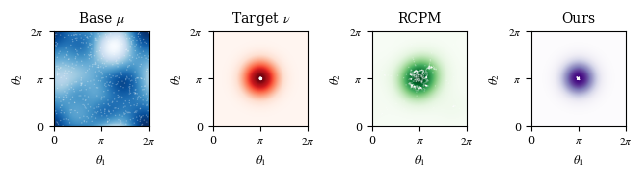

Saved: torus_flat_comparison.png/pdf


In [15]:
# =============================================================================
# FLAT TORUS VISUALIZATION (2D heatmap) - ICML FORMAT
# =============================================================================

# ICML-style plot settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

def plot_flat_torus(ax, samples_angles, title, cmap='viridis'):
    """
    Plot samples on flat torus [0, 2π) × [0, 2π).
    """
    # Compute density
    density, T1, T2 = compute_density_on_torus(samples_angles, n_grid=100)
    
    # Plot heatmap
    im = ax.pcolormesh(T1, T2, density, cmap=cmap, shading='auto')
    
    # Scatter samples on top
    ax.scatter(samples_angles[:500, 0], samples_angles[:500, 1], 
               s=1, alpha=0.3, c='white', edgecolors='none')
    
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 2*np.pi)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_title(title)
    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
    ax.set_yticks([0, np.pi, 2*np.pi])
    ax.set_yticklabels(['0', r'$\pi$', r'$2\pi$'])
    ax.set_aspect('equal')
    return im


fig, axes = plt.subplots(1, 4, figsize=(6.5, 1.8))  # ICML column width

plot_flat_torus(axes[0], base_angles, r'Base $\mu$', cmap='Blues')
plot_flat_torus(axes[1], target_angles, r'Target $\nu$', cmap='Reds')
plot_flat_torus(axes[2], rcpm_angles, 'RCPM', cmap='Greens')
im = plot_flat_torus(axes[3], ours_angles, 'Ours', cmap='Purples')

plt.tight_layout()
plt.savefig('torus_flat_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('torus_flat_comparison.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: torus_flat_comparison.png/pdf")

In [16]:
# =============================================================================
# COMPUTE
# =============================================================================

# Use same samples for fair comparison
key = jax.random.PRNGKey(999)
k1, k2 = jax.random.split(key)
n_eval = 256

# Sample from our base/target
xs = ours_exp['base'].sample(k1, n_eval)
ys_target = ours_exp['target'].sample(k2, n_eval)

# Transport with our method (pass target samples for logsumexp init)
ys_ours, _ = ours_exp['solver'].batch_solve(ours_exp['state'].params, xs, ys_target)

# RCPM always uses Product T2 (D=4), so convert FlatT2 samples to Product T2 embeddings
xs_angles = samples_to_angles(xs, ours_exp['manifold'])
xs_rcpm = angles_to_samples(xs_angles, rcpm_exp['manifold'])
ys_rcpm, _ = rcpm_exp['flow'].apply(rcpm_exp['params'], xs_rcpm)


In [17]:
# =============================================================================
# KL DIVERGENCE COMPARISON: Ours (IFT vs Autodiff) and RCPM
# =============================================================================
import time

print("="*60)
print("KL DIVERGENCE COMPARISON")
print("="*60)
print("\nKL(T#mu || nu) = E[log mu(x) - log nu(T(x)) - log|det J_T(x)|]")

# Use fewer samples for KL computation
n_kl = 1024  # Small for faster computation
key_kl = jax.random.PRNGKey(777)
xs_kl = ours_exp['base'].sample(key_kl, n_kl)

# Transport samples
ys_kl, residuals = ours_exp['solver'].batch_solve(
    ours_exp['state'].params, xs_kl, ys_target[:n_kl]
)
print(f"\nOurs solver residual: {float(jnp.mean(residuals)):.2e}")

# -----------------------------------------------------------------------------
# Method 1: Ours via IFT
# -----------------------------------------------------------------------------
print("\n[1] Ours (IFT)...")
t0 = time.time()
kl_ift = compute_kl_divergence(
    psi_params=ours_exp['state'].params,
    xs=xs_kl,
    ys=ys_kl,
    base_density=ours_exp['base'],
    target_density=ours_exp['target'],
    manifold=ours_exp['manifold'],
    psi_module=ours_exp['psi'],
)
t_ift = time.time() - t0
print(f"    Time: {t_ift:.2f}s")

# -----------------------------------------------------------------------------
# Method 2: Ours via Autodiff
# -----------------------------------------------------------------------------
print("\n[2] Ours (Autodiff)...")
t0 = time.time()
kl_autodiff = compute_kl_divergence_autodiff(
    psi_params=ours_exp['state'].params,
    xs=xs_kl,
    base_density=ours_exp['base'],
    target_density=ours_exp['target'],
    solver=ours_exp['solver'],
    manifold=ours_exp['manifold'],
    y_samples=ys_target,
)
t_autodiff = time.time() - t0
print(f"    Time: {t_autodiff:.2f}s")

# -----------------------------------------------------------------------------
# Method 3: RCPM (with ESS)
# -----------------------------------------------------------------------------
print("\n[3] RCPM...")
t0 = time.time()

# Sample from RCPM base
key_rcpm = jax.random.PRNGKey(778)
rcpm_xs = rcpm_exp['base'].sample(key_rcpm, n_kl)

# Transport and get log det jacobians
rcpm_ys, rcpm_ldjs = rcpm_exp['flow'].apply(rcpm_exp['params'], rcpm_xs)

# Compute KL components
rcpm_log_mu = rcpm_exp['base'].log_prob(rcpm_xs)
rcpm_log_nu = rcpm_exp['target'].log_prob(rcpm_ys)

# KL = E[log mu - ldj - log nu]
rcpm_kl_per_sample = rcpm_log_mu - rcpm_ldjs - rcpm_log_nu
rcpm_kl = float(jnp.mean(rcpm_kl_per_sample))

# ESS from importance weights
rcpm_log_weights = -rcpm_kl_per_sample
rcpm_ess, rcpm_ess_ratio = compute_ess(rcpm_log_weights)

t_rcpm = time.time() - t0
print(f"    Time: {t_rcpm:.2f}s")

# -----------------------------------------------------------------------------
# Comparison Table
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print(f"RESULTS (N={n_kl} samples)")
print("="*60)
print(f"{'Method':<25} {'KL':>12} {'ESS ratio':>12} {'Time (s)':>10}")
print("-"*60)
print(f"{'Ours (IFT)':<25} {kl_ift.kl:>12.4f} {kl_ift.ess_ratio*100:>11.1f}% {t_ift:>10.2f}")
print(f"{'Ours (Autodiff)':<25} {kl_autodiff.kl:>12.4f} {kl_autodiff.ess_ratio*100:>11.1f}% {t_autodiff:>10.2f}")
print(f"{'RCPM':<25} {rcpm_kl:>12.4f} {rcpm_ess_ratio*100:>11.1f}% {t_rcpm:>10.2f}")
print("-"*60)


KL DIVERGENCE COMPARISON

KL(T#mu || nu) = E[log mu(x) - log nu(T(x)) - log|det J_T(x)|]

Ours solver residual: 1.36e-07

[1] Ours (IFT)...
    Time: 43.41s

[2] Ours (Autodiff)...
    Time: 27.67s

[3] RCPM...
    Time: 2.78s

RESULTS (N=1024 samples)
Method                              KL    ESS ratio   Time (s)
------------------------------------------------------------
Ours (IFT)                      0.9441        58.2%      43.41
Ours (Autodiff)                 0.9414        58.2%      27.67
RCPM                            5.2319         6.9%       2.78
------------------------------------------------------------


/tmp/ipykernel_382211/3683038727.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm(density_surf))


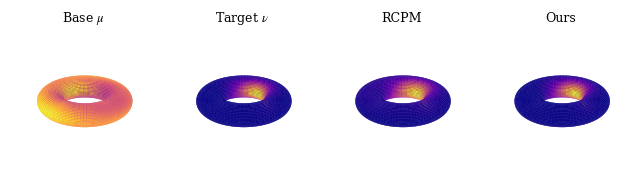

Saved: torus_figure5_style.png/pdf


In [18]:
# =============================================================================
# PUBLICATION-QUALITY FIGURE - ICML FORMAT
# =============================================================================

def plot_3d_torus_density(ax, samples_angles, title, cmap='plasma', R=2.0, r=0.8):
    """
    Plot density on 3D torus surface.
    
    samples_angles: (N, 2) array of angles (θ1, θ2)
    """
    from scipy.interpolate import RegularGridInterpolator
    
    # Create torus surface mesh (higher resolution for smoothness)
    n_theta1, n_theta2 = 100, 50
    theta1 = np.linspace(0, 2*np.pi, n_theta1)
    theta2 = np.linspace(0, 2*np.pi, n_theta2)
    T1, T2 = np.meshgrid(theta1, theta2)
    
    x_surf = (R + r * np.cos(T2)) * np.cos(T1)
    y_surf = (R + r * np.cos(T2)) * np.sin(T1)
    z_surf = r * np.sin(T2)
    
    # Compute density on a grid matching the interpolator
    n_grid = 100
    density, _, _ = compute_density_on_torus(samples_angles, n_grid=n_grid)
    
    # Interpolate density to surface mesh
    theta1_grid = np.linspace(0, 2*np.pi, n_grid)
    theta2_grid = np.linspace(0, 2*np.pi, n_grid)
    interp = RegularGridInterpolator((theta2_grid, theta1_grid), density,
                                      bounds_error=False, fill_value=0)
    
    points = np.stack([T2.ravel() % (2*np.pi), T1.ravel() % (2*np.pi)], axis=1)
    density_surf = interp(points).reshape(T1.shape)
    
    # Map density to colors
    norm = plt.Normalize(vmin=density_surf.min(), vmax=density_surf.max())
    colors = plt.cm.get_cmap(cmap)(norm(density_surf))
    
    # Plot surface
    ax.plot_surface(x_surf, y_surf, z_surf, facecolors=colors,
                    rstride=1, cstride=1, linewidth=0, antialiased=True, shade=False)
    
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-1.5, 1.5)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 0.4])  # Flatten the view slightly
    
    return ax


# ICML-style plot settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig = plt.figure(figsize=(6.5, 1.8))  # ICML column width

# Create 3D subplots
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
ax4 = fig.add_subplot(1, 4, 4, projection='3d')

# Use same colormap for all (like original RCPM paper)
cmap = 'plasma'

plot_3d_torus_density(ax1, base_angles, r'Base $\mu$', cmap=cmap)
plot_3d_torus_density(ax2, target_angles, r'Target $\nu$', cmap=cmap)
plot_3d_torus_density(ax3, rcpm_angles, 'RCPM', cmap=cmap)
plot_3d_torus_density(ax4, ours_angles, 'Ours', cmap=cmap)

# Adjust viewing angle for all
for ax in [ax1, ax2, ax3, ax4]:
    ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.savefig('torus_figure5_style.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('torus_figure5_style.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: torus_figure5_style.png/pdf")

In [ ]:
# =============================================================================
# PUBLICATION FIGURE: 2x2 with Latitude Band Flow Lines + Arrows
# =============================================================================

def plot_3d_torus_density_only(ax, samples_angles, title, cmap='plasma', R=2.0, r=0.8):
    """Plot 3D torus with density coloring only (no flow lines)."""
    from scipy.interpolate import RegularGridInterpolator
    
    # Create torus surface mesh
    n_theta1, n_theta2 = 100, 50
    theta1 = np.linspace(0, 2*np.pi, n_theta1)
    theta2 = np.linspace(0, 2*np.pi, n_theta2)
    T1, T2 = np.meshgrid(theta1, theta2)
    
    x_surf = (R + r * np.cos(T2)) * np.cos(T1)
    y_surf = (R + r * np.cos(T2)) * np.sin(T1)
    z_surf = r * np.sin(T2)
    
    # Compute density
    density, _, _ = compute_density_on_torus(samples_angles, n_grid=100)
    
    # Interpolate density to surface mesh
    n_grid = 100
    theta1_grid = np.linspace(0, 2*np.pi, n_grid)
    theta2_grid = np.linspace(0, 2*np.pi, n_grid)
    interp = RegularGridInterpolator((theta2_grid, theta1_grid), density,
                                      bounds_error=False, fill_value=0)
    
    points = np.stack([T2.ravel() % (2*np.pi), T1.ravel() % (2*np.pi)], axis=1)
    density_surf = interp(points).reshape(T1.shape)
    
    # Map density to colors
    norm = plt.Normalize(vmin=density_surf.min(), vmax=density_surf.max())
    colors = plt.colormaps.get_cmap(cmap)(norm(density_surf))
    
    # Plot surface
    ax.plot_surface(x_surf, y_surf, z_surf, facecolors=colors,
                    rstride=1, cstride=1, linewidth=0, antialiased=True, 
                    shade=False, zorder=1)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=5)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-1.5, 1.5)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 0.4])
    return ax


def plot_3d_torus_with_latitude_flows(ax, title, solver, state_params, manifold,
                                       target_samples, cmap='Greys', R=2.0, r=0.8,
                                       flow_cmap='plasma', line_width=1.5,
                                       n_latitudes=12, n_points_per_lat=20,
                                       line_alpha=0.9, show_surface=True,
                                       surface_alpha=0.3, show_arrows=True,
                                       arrow_scale=0.3):
    """
    Plot 3D torus with flow lines sampled along latitude bands.
    
    manifold: manifold used by solver (FlatT2 or Product T2)
    n_latitudes: number of θ2 values (latitude circles)
    n_points_per_lat: number of points per latitude circle
    show_arrows: if True, draw direction arrows at midpoint of each flow
    arrow_scale: size of the arrows
    """
    from scipy.interpolate import RegularGridInterpolator
    
    # Create torus surface mesh
    n_theta1, n_theta2 = 100, 50
    theta1_surf = np.linspace(0, 2*np.pi, n_theta1)
    theta2_surf = np.linspace(0, 2*np.pi, n_theta2)
    T1, T2 = np.meshgrid(theta1_surf, theta2_surf)
    
    x_surf = (R + r * np.cos(T2)) * np.cos(T1)
    y_surf = (R + r * np.cos(T2)) * np.sin(T1)
    z_surf = r * np.sin(T2)
    
    if show_surface:
        # Light gray surface
        colors = np.ones((*T1.shape, 4)) * 0.75  # Light gray
        colors[:, :, 3] = surface_alpha
        ax.plot_surface(x_surf, y_surf, z_surf, facecolors=colors,
                        rstride=1, cstride=1, linewidth=0, antialiased=True, 
                        shade=False, zorder=1)
    
    # Generate latitude-band points
    lat_t2_values = np.linspace(0, 2*np.pi, n_latitudes, endpoint=False)
    
    all_src_angles = []
    all_dst_angles = []
    all_geodesic_dists = []
    all_dt = []
    
    for t2_val in lat_t2_values:
        # Points along this latitude (varying θ1, fixed θ2)
        t1_values = np.linspace(0, 2*np.pi, n_points_per_lat, endpoint=False)
        
        for t1_val in t1_values:
            src = np.array([t1_val, t2_val])
            all_src_angles.append(src)
    
    all_src_angles = np.array(all_src_angles)
    
    # Convert angles to manifold samples and transport
    src_samples = angles_to_samples(all_src_angles, manifold)
    dst_samples, _ = solver.batch_solve(state_params, src_samples, 
                                         target_samples[:len(all_src_angles)])
    dst_angles = np.array(samples_to_angles(dst_samples, manifold))
    
    # Compute shortest paths
    for i in range(len(all_src_angles)):
        src = all_src_angles[i]
        dst = dst_angles[i]
        
        dt1 = dst[0] - src[0]
        dt2 = dst[1] - src[1]
        
        if dt1 > np.pi: dt1 -= 2*np.pi
        elif dt1 < -np.pi: dt1 += 2*np.pi
        if dt2 > np.pi: dt2 -= 2*np.pi
        elif dt2 < -np.pi: dt2 += 2*np.pi
        
        geodesic_dist = np.sqrt(dt1**2 + dt2**2)
        all_geodesic_dists.append(geodesic_dist)
        all_dt.append((dt1, dt2))
        all_dst_angles.append(dst)
    
    max_dist = max(all_geodesic_dists) if all_geodesic_dists else 1.0
    flow_colormap = plt.colormaps.get_cmap(flow_cmap)
    lift = 0.04  # Lift lines above surface
    
    # Store arrow data for drawing after lines
    arrow_data = []
    
    # Draw flow lines
    for idx in range(len(all_src_angles)):
        src = all_src_angles[idx]
        dt1, dt2 = all_dt[idx]
        total_dist = all_geodesic_dists[idx]
        
        n_interp = 40
        t = np.linspace(0, 1, n_interp)
        t1_path = src[0] + t * dt1
        t2_path = src[1] + t * dt2
        
        x_path = (R + (r + lift) * np.cos(t2_path)) * np.cos(t1_path)
        y_path = (R + (r + lift) * np.cos(t2_path)) * np.sin(t1_path)
        z_path = (r + lift) * np.sin(t2_path)
        
        # Color by cumulative distance (scaled by max)
        for j in range(n_interp - 1):
            progress = (j + 0.5) / (n_interp - 1)
            cumulative_dist = progress * total_dist
            color_val = cumulative_dist / max_dist
            color = flow_colormap(color_val)
            
            ax.plot([x_path[j], x_path[j+1]], 
                   [y_path[j], y_path[j+1]], 
                   [z_path[j], z_path[j+1]],
                   color=color, linewidth=line_width, alpha=line_alpha,
                   solid_capstyle='round', zorder=10)
        
        # Store midpoint arrow data
        if show_arrows and total_dist > 0.1:  # Only show arrows for non-trivial flows
            mid_idx = n_interp // 2
            # Position at midpoint
            mid_x, mid_y, mid_z = x_path[mid_idx], y_path[mid_idx], z_path[mid_idx]
            # Direction from nearby points (use wider spread for better direction estimate)
            dx = x_path[mid_idx + 2] - x_path[mid_idx - 2]
            dy = y_path[mid_idx + 2] - y_path[mid_idx - 2]
            dz = z_path[mid_idx + 2] - z_path[mid_idx - 2]
            # Normalize and scale
            norm_val = np.sqrt(dx**2 + dy**2 + dz**2)
            if norm_val > 1e-6:
                dx, dy, dz = dx/norm_val * arrow_scale, dy/norm_val * arrow_scale, dz/norm_val * arrow_scale
                # Color at midpoint
                color_val = 0.5 * total_dist / max_dist
                arrow_color = flow_colormap(color_val)
                arrow_data.append((mid_x, mid_y, mid_z, dx, dy, dz, arrow_color))
    
    # Draw arrows using quiver (renders well in PNG)
    if show_arrows and arrow_data:
        for (ax_x, ax_y, ax_z, dx, dy, dz, color) in arrow_data:
            ax.quiver(ax_x - dx*0.5, ax_y - dy*0.5, ax_z - dz*0.5,
                     dx, dy, dz, 
                     color=color, 
                     arrow_length_ratio=0.4,
                     linewidth=1.5,
                     zorder=25)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=5)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-1.5, 1.5)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 0.4])
    
    return ax, len(all_src_angles)


# =============================================================================
# Create figure with tight layout
# =============================================================================
DENSITY_CMAP = 'plasma'  # Consistent colormap for all density plots

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.titlesize': 14,
})

fig = plt.figure(figsize=(10, 9))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

# Top-left: Base distribution (uniform)
plot_3d_torus_density_only(ax1, base_angles, r'(a) Source $\mu$ (Uniform)', cmap=DENSITY_CMAP)

# Top-right: Target distribution (wrapped normal)
plot_3d_torus_density_only(ax2, target_angles, r'(b) Target $\nu$ (Wrapped Normal)', cmap=DENSITY_CMAP)

# Bottom-left: Transport with LATITUDE BAND flow lines + arrows
ax3, n_lines = plot_3d_torus_with_latitude_flows(
    ax3, 
    title=r'(c) Optimal Transport Map $T$',
    solver=ours_exp['solver'],
    state_params=ours_exp['state'].params,
    manifold=ours_exp['manifold'],  # Pass manifold parameter
    target_samples=target_samples_ours,
    flow_cmap='plasma',
    n_latitudes=10,
    n_points_per_lat=20,
    line_width=0.6,
    line_alpha=0.6,
    surface_alpha=0.3,      # Grey torus underneath
    show_arrows=True,       # Add direction arrows
    arrow_scale=0.2,        # Arrow size
)

# Bottom-right: Transported distribution (pushforward)
plot_3d_torus_density_only(ax4, ours_angles, r'(d) Pushforward $T_\#\mu$', cmap=DENSITY_CMAP)

# Set viewing angles
for ax in [ax1, ax2, ax3, ax4]:
    ax.view_init(elev=30, azim=45)

# Reduce white space
plt.subplots_adjust(left=0, right=1, bottom=0, top=0.92, wspace=-0.1, hspace=0.05)

# Save as PNG (arrows render correctly in PNG)
plt.savefig('torus_ot_figure.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nDrawn {n_lines} flow lines from 8 latitude bands with direction arrows")
print("Saved: torus_ot_figure.png")

KeyboardInterrupt: 

In [ ]:
# =============================================================================
# EXPORT INDIVIDUAL PANELS FOR LATEX (PNG - arrows render correctly)
# =============================================================================
DENSITY_CMAP = 'plasma'  # Same as main figure

for i, (ax_func, angles, title, cmap, fname) in enumerate([
    (plot_3d_torus_density_only, base_angles, r'Source $\mu$', DENSITY_CMAP, 'torus_a_source'),
    (plot_3d_torus_density_only, target_angles, r'Target $\nu$', DENSITY_CMAP, 'torus_b_target'),
    (None, None, r'Transport $T$', None, 'torus_c_transport'),  # Special case
    (plot_3d_torus_density_only, ours_angles, r'Pushforward $T_\#\mu$', DENSITY_CMAP, 'torus_d_pushforward'),
]):
    # Smaller figure, will crop tight
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    
    if fname == 'torus_c_transport':
        plot_3d_torus_with_latitude_flows(
            ax, title='', solver=ours_exp['solver'],
            state_params=ours_exp['state'].params,
            manifold=ours_exp['manifold'],  # Pass manifold parameter
            target_samples=target_samples_ours,
            flow_cmap='plasma', n_latitudes=10, n_points_per_lat=20,
            line_width=1.5, line_alpha=0.6, surface_alpha=0.3,
            show_arrows=True, arrow_scale=0.2,
        )
    else:
        ax_func(ax, angles, '', cmap=cmap)
    
    ax.view_init(elev=30, azim=45)
    
    # Tighter axis limits to reduce whitespace
    ax.set_xlim(-2.8, 2.8)
    ax.set_ylim(-2.8, 2.8)
    ax.set_zlim(-1.2, 1.2)
    
    # Remove all margins
    ax.set_position([0, 0, 1, 1])  # Fill entire figure
    
    # Save as PNG (arrows render correctly)
    plt.savefig(f'{fname}.png', dpi=300, bbox_inches='tight', pad_inches=0, facecolor='white')
    plt.close()
    print(f"Saved: {fname}.png")